# 00 — Foundations of Machine Learning

Before touching any algorithm, we need a shared vocabulary and a few core ideas
that every model in this syllabus will be judged against: **what kind of
problem are we solving**, and **is the model generalizing or just memorizing**?

**In this notebook:**
1. Types of machine learning
2. Bias-variance tradeoff (with a live visual demo)
3. Overfitting vs. underfitting
4. Train/test split & cross-validation, visualized
5. A fast NumPy / Pandas / Matplotlib refresher

## 1. Types of Machine Learning

| Type | What it learns from | Example algorithms | Example task |
|---|---|---|---|
| **Supervised** | Labeled data `(X, y)` | Linear/Logistic Regression, Trees, SVM | Predict house price, classify email as spam |
| **Unsupervised** | Unlabeled data `X` only | K-Means, PCA, DBSCAN | Customer segmentation, dimensionality reduction |
| **Reinforcement** | Reward signal from interacting with an environment | Q-Learning, Policy Gradients | Game playing, robotics (out of scope here) |

This syllabus focuses on **supervised** (regression + classification) and
**unsupervised** learning, since that's what scikit-learn is built around.

Within supervised learning there are two families of tasks:
- **Regression** — predict a continuous number (e.g., price, temperature)
- **Classification** — predict a discrete category (e.g., spam/not-spam)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

## 2. Bias-Variance Tradeoff

Every model's prediction error can be decomposed into three parts:

$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise} $$

- **Bias** — error from overly simplistic assumptions (the model can't capture the true pattern). High bias → **underfitting**.
- **Variance** — error from being too sensitive to the specific training data (the model captures noise). High variance → **overfitting**.
- There's an inherent tradeoff: as model complexity increases, bias tends to fall while variance rises.

Let's make this concrete by fitting polynomials of increasing degree to noisy
data generated from a known true function, and watching train vs. test error diverge.

In [2]:
# Generate synthetic data from a known non-linear function + noise
def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_samples = 40
X = rng.uniform(0, 1, n_samples)
y = true_function(X) + rng.normal(scale=0.25, size=n_samples)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

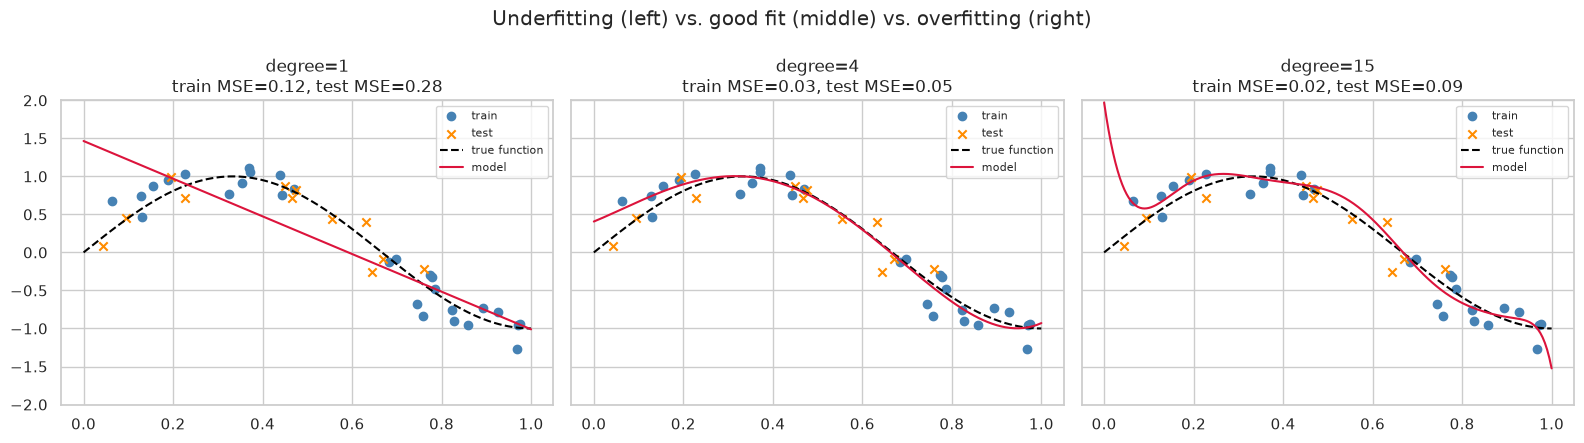

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

degrees = [1, 4, 15]
x_plot = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, degree in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train.reshape(-1, 1), y_train)

    ax.scatter(X_train, y_train, label="train", color="steelblue")
    ax.scatter(X_test, y_test, label="test", color="darkorange", marker="x")
    ax.plot(x_plot, true_function(x_plot), label="true function", color="black", linestyle="--")
    ax.plot(x_plot, model.predict(x_plot.reshape(-1, 1)), label="model", color="crimson")
    ax.set_ylim(-2, 2)

    train_err = mean_squared_error(y_train, model.predict(X_train.reshape(-1, 1)))
    test_err = mean_squared_error(y_test, model.predict(X_test.reshape(-1, 1)))
    ax.set_title(f"degree={degree}\ntrain MSE={train_err:.2f}, test MSE={test_err:.2f}")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Underfitting (left) vs. good fit (middle) vs. overfitting (right)")
plt.tight_layout()
plt.show()

**Reading the plot:**
- **degree=1** (left): a straight line can't capture the curve — high bias, *underfitting*. Both train and test error are high.
- **degree=4** (middle): flexible enough to follow the true curve without chasing noise — the sweet spot.
- **degree=15** (right): the model contorts itself to pass through training points exactly — high variance, *overfitting*. Train error looks great, test error is much worse.

This train/test error gap **is** the signature of overfitting, and it's the reason we never evaluate a model only on the data it was trained on.

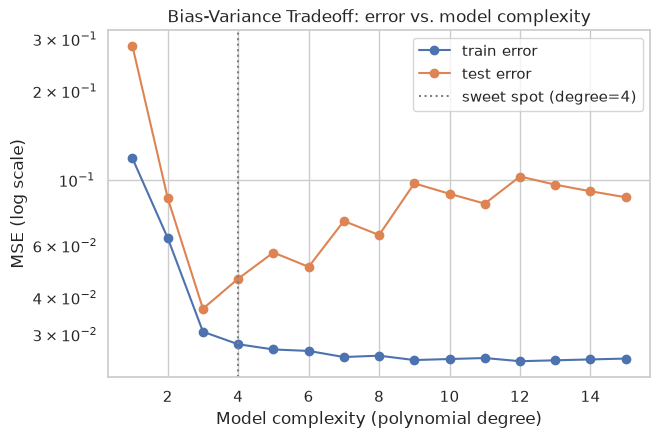

In [4]:
# Quantify the tradeoff: sweep polynomial degree, plot train vs. test error
degree_range = range(1, 16)
train_errors, test_errors = [], []

for degree in degree_range:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train.reshape(-1, 1), y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(X_train.reshape(-1, 1))))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test.reshape(-1, 1))))

plt.figure(figsize=(7, 4.5))
plt.plot(degree_range, train_errors, marker="o", label="train error")
plt.plot(degree_range, test_errors, marker="o", label="test error")
plt.axvline(4, color="gray", linestyle=":", label="sweet spot (degree=4)")
plt.yscale("log")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("MSE (log scale)")
plt.title("Bias-Variance Tradeoff: error vs. model complexity")
plt.legend()
plt.show()

Notice the classic **U-shape** in the test error curve: it falls as complexity
increases (bias shrinks), bottoms out, then rises again (variance takes over).
Nearly every model-selection technique in this syllabus (cross-validation,
regularization, hyperparameter tuning) is, at its core, a way to find that
bottom of the U.

## 3. Train/Test Split & Cross-Validation

A single train/test split gives one estimate of test performance, which can be
noisy — it depends on which points happened to land in the test set. **K-Fold
Cross-Validation** reduces this noise by splitting the data into *K* folds,
training on K-1 of them and validating on the remaining fold, K times, then
averaging the results.

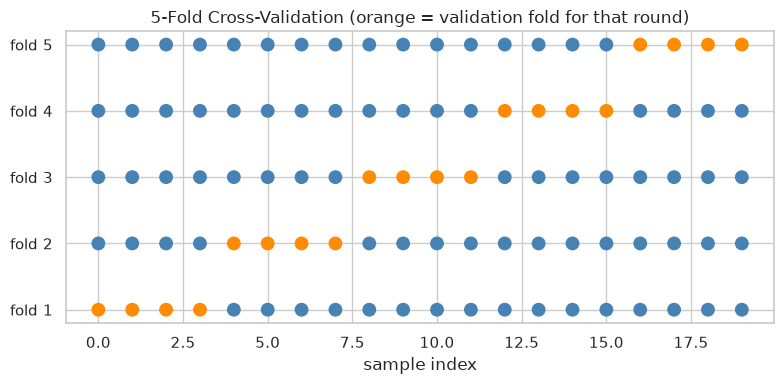

In [5]:
from sklearn.model_selection import KFold

fig, ax = plt.subplots(figsize=(8, 4))
n_points, n_splits = 20, 5
kf = KFold(n_splits=n_splits)

for fold, (train_idx, val_idx) in enumerate(kf.split(range(n_points))):
    colors = np.array(["steelblue"] * n_points, dtype=object)
    colors[val_idx] = "darkorange"
    ax.scatter(range(n_points), [fold] * n_points, c=list(colors), s=80)

ax.set_yticks(range(n_splits))
ax.set_yticklabels([f"fold {i+1}" for i in range(n_splits)])
ax.set_xlabel("sample index")
ax.set_title("5-Fold Cross-Validation (orange = validation fold for that round)")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import cross_val_score

model = make_pipeline(PolynomialFeatures(4), LinearRegression())
scores = cross_val_score(model, X.reshape(-1, 1), y, cv=5, scoring="neg_mean_squared_error")
print("Per-fold MSE:", -scores)
print(f"Mean MSE: {-scores.mean():.3f}  (+/- {scores.std():.3f})")

Per-fold MSE: [0.03389918 0.03262401 0.06603945 0.06086988 0.02019847]
Mean MSE: 0.043  (+/- 0.018)


We'll use `cross_val_score`, `KFold`, and `StratifiedKFold` throughout this
syllabus — every module from `02_regression` onward evaluates models this way
rather than trusting a single split.

## 4. NumPy / Pandas / Matplotlib Refresher

A quick reminder of the operations we'll lean on constantly: array math,
tabular data handling, and plotting.

In [7]:
# NumPy: vectorized array math
arr = np.array([1, 2, 3, 4, 5])
print("array:", arr)
print("mean:", arr.mean(), "| std:", arr.std())
print("squared:", arr ** 2)
print("boolean mask (>2):", arr[arr > 2])

array: [1 2 3 4 5]
mean: 3.0 | std: 1.4142135623730951
squared: [ 1  4  9 16 25]
boolean mask (>2): [3 4 5]


In [8]:
# Pandas: tabular data
df = pd.DataFrame({
    "feature_a": rng.normal(size=6),
    "feature_b": rng.integers(0, 10, size=6),
    "label": ["yes", "no", "yes", "yes", "no", "no"],
})
display(df)
print()
print(df.groupby("label")["feature_a"].mean())

,feature_a,feature_b,label
0,0.456775,7,yes
1,-0.661926,1,no
2,-0.363054,9,yes
3,-0.381738,5,yes
4,-1.195840,9,no
5,0.486972,1,no



label
no    -0.456931
yes   -0.096006
Name: feature_a, dtype: float64


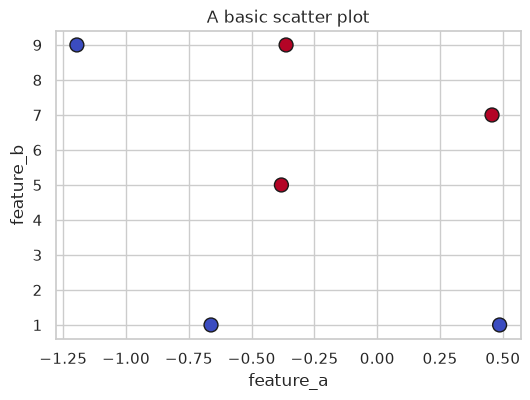

In [9]:
# Matplotlib: the plotting primitives we'll reuse everywhere
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["feature_a"], df["feature_b"], c=(df["label"] == "yes"), cmap="coolwarm", s=100, edgecolor="k")
ax.set_xlabel("feature_a")
ax.set_ylabel("feature_b")
ax.set_title("A basic scatter plot")
plt.show()

## Exercises

1. Re-run the bias-variance experiment with `n_samples = 200` instead of 40. Does overfitting at degree=15 become less severe? Why?
2. Change `n_splits` in the K-Fold demo to 10 and re-plot. How does the visualization change?
3. In the Pandas example, compute the mean of `feature_b` grouped by `label` instead of `feature_a`.

## Key Takeaways

- ML splits into supervised (regression/classification), unsupervised, and reinforcement learning.
- Every model balances **bias** (underfitting) against **variance** (overfitting) — model complexity is the dial.
- Never trust training error alone — always hold out test data, and prefer cross-validation over a single split when data is limited.